In [1]:
import pickle
from dython.nominal import associations
from sklearn.svm import LinearSVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
from numpy import load
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score, cross_validate
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import shuffle
from IPython.display import display

In [2]:
with open('X.pickle', 'rb') as handle:
    load_X = pickle.load(handle)

with open('Y.pickle', 'rb') as handle:
    load_Y = pickle.load(handle)

X = pd.DataFrame(load_X, columns=["i", "j", "R_ij", "bond_order", "1st_nei"])
y = pd.DataFrame(load_Y)

   i  j      R_ij  bond_order      1st_nei
0  C  C  0.151457       0.986  [CHHH, CCO]
1  C  C  0.153065       0.935  [CCO, CCCH]
2  C  O  0.122295       1.864     [CCO, C]
3  H  C  0.109654       0.925    [C, CHHH]
4  C  H  0.109250       0.939    [CHHH, C]
   i  j      R_ij  bond_order i_nei j_nei
0  C  C  0.151457       0.986  CHHH   CCO
1  C  C  0.153065       0.935   CCO  CCCH
2  C  O  0.122295       1.864   CCO     C
3  H  C  0.109654       0.925     C  CHHH
4  C  H  0.109250       0.939  CHHH     C
       i  j      R_ij  bond_order i_nei j_nei
11639  C  H  0.109986       0.924  CCHH     C
11640  C  C  0.133457       1.976   CCH   CHH
11641  H  C  0.109139       0.929     C   CCH
11642  C  H  0.108761       0.935   CHH     C
11643  C  H  0.108941       0.934   CHH     C


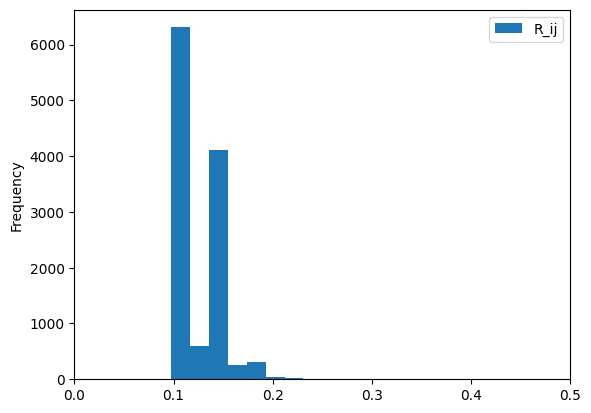

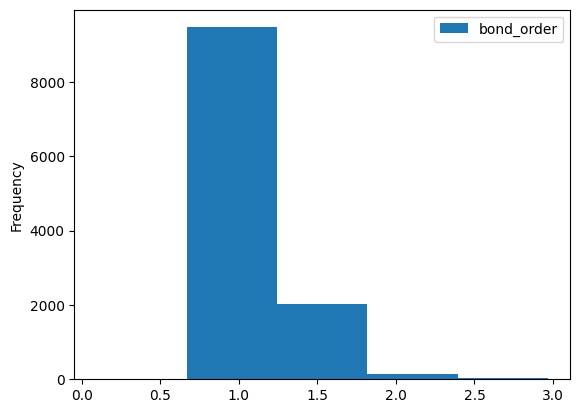

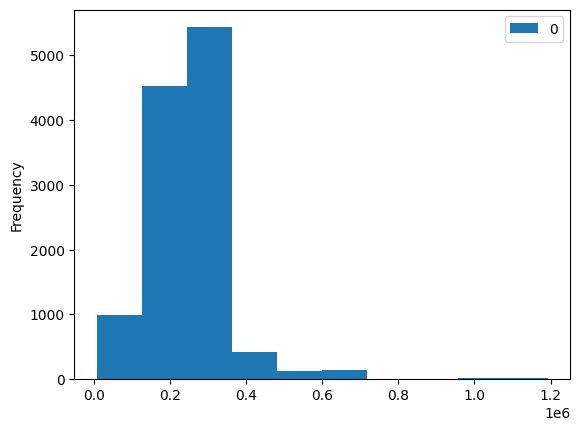

In [3]:
print(X.head())
X.plot.hist(column="R_ij", bins=150, xlim=(0,0.5))
X.plot.hist(column="bond_order", bins=5)
y.plot.hist()
X[["i_nei", "j_nei"]] = X["1st_nei"].tolist()
X.drop(columns="1st_nei", inplace=True)
print(X.head())
print(X.tail())

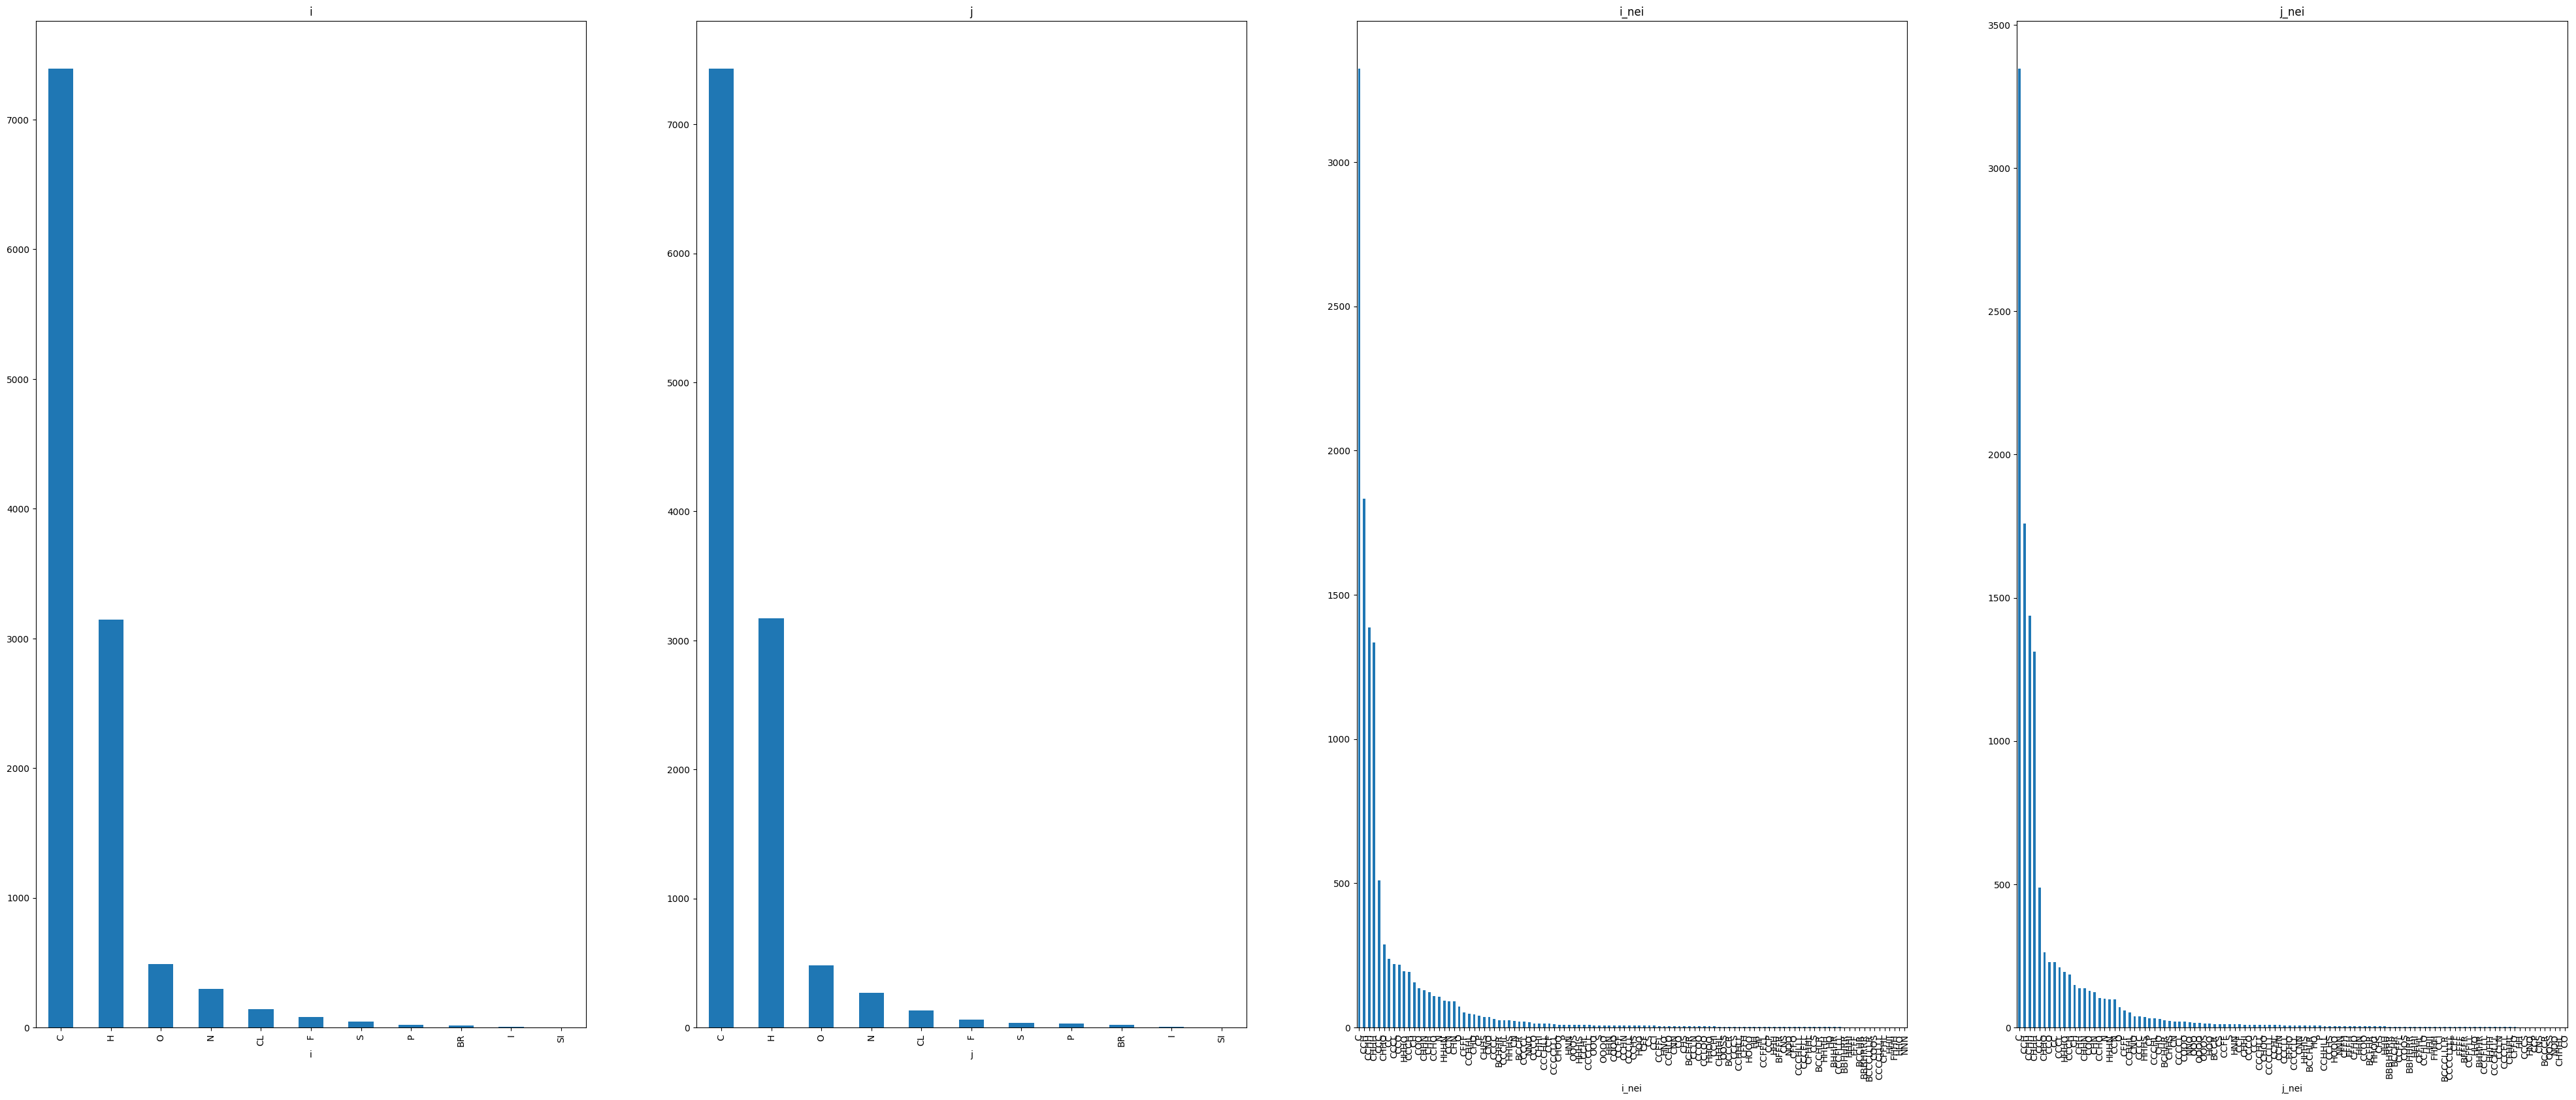

In [4]:
cat_features = ['i', 'j', 'i_nei', 'j_nei']
fig, ax = plt.subplots(1, len(cat_features), figsize=(50,20))

for i, cat_feature in enumerate(X[cat_features]):
    X[cat_feature].value_counts().plot(kind="bar",
                                          title=cat_feature, 
                                          ax=ax[i], )

   i  j      R_ij  bond_order i_nei j_nei              0
0  C  C  0.151457       0.986  CHHH   CCO  210370.994384
1  C  C  0.153065       0.935   CCO  CCCH  170191.015964
2  C  O  0.122295       1.864   CCO     C  582504.176736
3  H  C  0.109654       0.925     C  CHHH  297537.484712
4  C  H  0.109250       0.939  CHHH     C  262769.659802


/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:736: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[i], columns[j]] = _inf_nan_str(ij)
/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:737: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[j], columns[i]] = _inf_nan_str(ji)


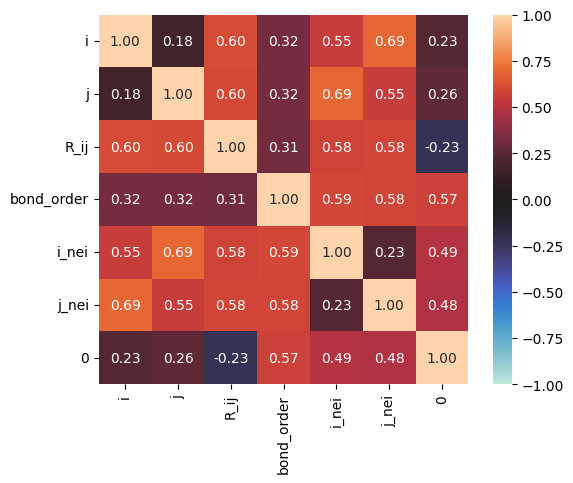

In [5]:
joint=X.join(y)
print(joint.head())
complete_correlation= associations(joint)

In [6]:
def one_hot_encode_column(df: pd.DataFrame, col: int, pref: str = None) -> pd.DataFrame:
    encoded_column = pd.get_dummies(df[col], prefix=pref)
    df.drop(col, axis=1, inplace=True)
    # try:
    df = df.join(encoded_column)
    # except ValueError as verr:
    #     if "overlap" in verr.__str__():
    #         df = df.merge(encoded_column, left_on="BR", right_on="BR")

    return df

In [7]:
X = one_hot_encode_column(X, "i", "i")
X = one_hot_encode_column(X, "j", "j")
X = one_hot_encode_column(X, "i_nei", "i_nei")
X = one_hot_encode_column(X, "j_nei", "j_nei")


X.columns = X.columns.map(str)


In [8]:
print(X.head())

       R_ij  bond_order   i_BR    i_C   i_CL    i_F    i_H    i_I    i_N  \
0  0.151457       0.986  False   True  False  False  False  False  False   
1  0.153065       0.935  False   True  False  False  False  False  False   
2  0.122295       1.864  False   True  False  False  False  False  False   
3  0.109654       0.925  False  False  False  False   True  False  False   
4  0.109250       0.939  False   True  False  False  False  False  False   

     i_O  ...  j_nei_NNN  j_nei_NNO  j_nei_NOO  j_nei_O  j_nei_OOO  \
0  False  ...      False      False      False    False      False   
1  False  ...      False      False      False    False      False   
2  False  ...      False      False      False    False      False   
3  False  ...      False      False      False    False      False   
4  False  ...      False      False      False    False      False   

   j_nei_OOOO  j_nei_OOOS  j_nei_OOSS  j_nei_P  j_nei_S  
0       False       False       False    False    False  
1     

<Axes: ylabel='Frequency'>

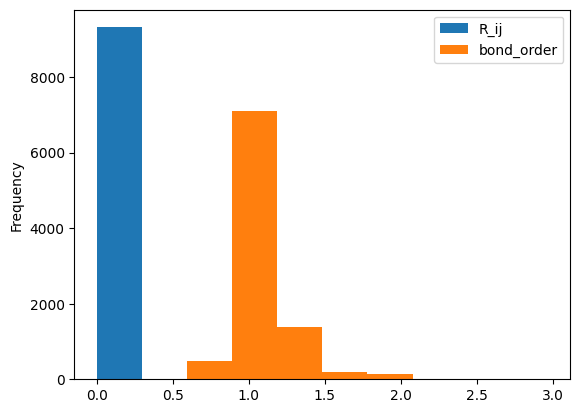

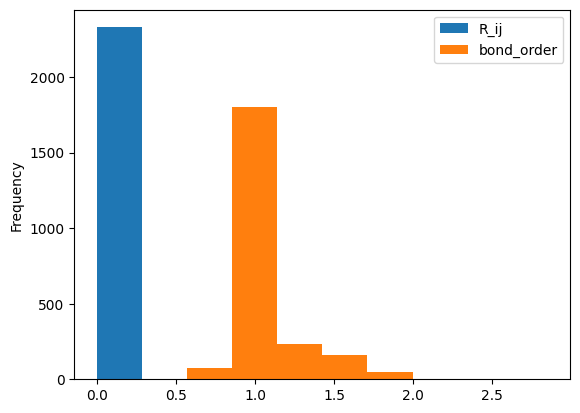

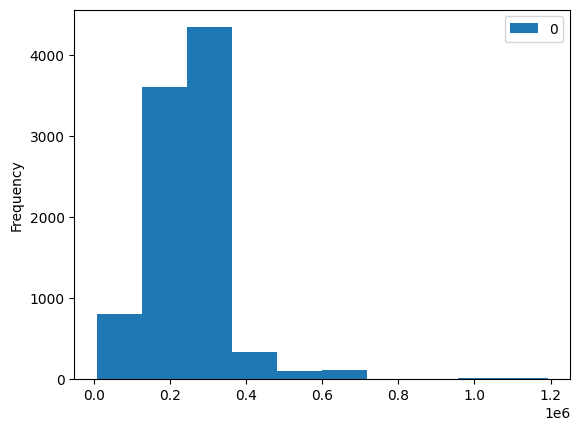

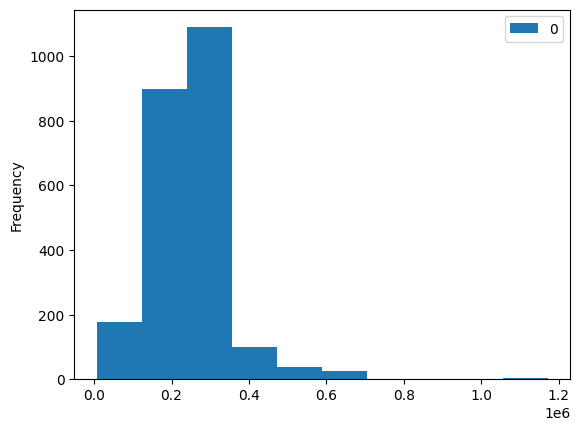

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)
X_train.plot.hist()
X_test.plot.hist()
y_train.plot.hist()
y_test.plot.hist()

In [12]:
X_shuf, y_shuf = shuffle(X, y)
train_sizes = np.linspace(0.1, 1, 500)
train_size_abs, train_scores, test_scores = learning_curve(LinearRegression(), X_shuf, y_shuf, shuffle = True, train_sizes=train_sizes)

[-4.47082209e+22 -3.67377564e+21 -2.30881963e+22 -4.89478441e+22
 -1.24052384e+22 -2.08689944e+22 -1.28952543e+24 -6.06177054e+23
 -2.81732606e+22 -1.08755639e+22 -9.20076110e+21 -3.47230724e+23
 -5.41801792e+23 -1.42554946e+22 -1.72586497e+22 -3.74115507e+23
 -1.69621940e+24 -8.45693825e+21 -2.29679244e+22 -2.64759346e+21
 -2.79853565e+22 -6.26875490e+21 -7.40682705e+21 -5.54728136e+21
 -1.55664504e+22 -1.36800255e+22 -1.70882074e+22 -3.10109122e+21
 -2.85448891e+22 -2.82803259e+23 -4.33054424e+21 -1.39351480e+22
 -4.60099534e+21 -5.25563095e+21 -1.51186108e+22 -1.55419777e+22
 -1.39860444e+22 -1.22267979e+22 -1.34419807e+22 -7.39763151e+21
 -5.77537086e+20 -1.83975837e+21 -4.39527629e+21 -1.76084129e+22
 -1.21579202e+22 -1.07485794e+21 -4.34148975e+20 -1.30144456e+21
 -5.45464221e+20 -7.85376549e+21 -8.63601647e+21 -9.70464837e+21
 -3.53924056e+21 -7.09952218e+21 -2.20784806e+21 -6.62205692e+20
 -2.45577596e+20 -1.52892007e+21 -3.09743284e+21 -4.57325938e+21
 -1.77834610e+21 -2.98008

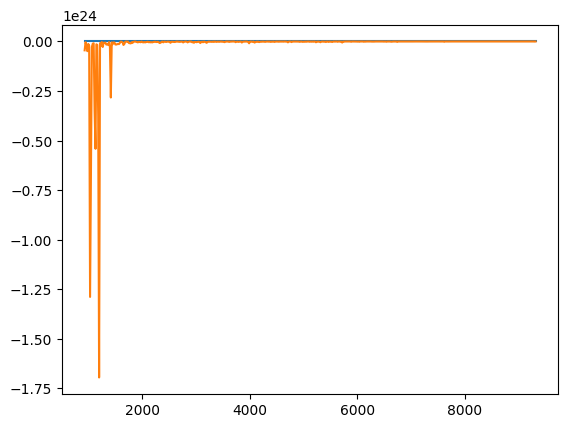

In [13]:
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)
plt.plot(train_size_abs, train_scores_mean)
plt.plot(train_size_abs, test_scores_mean)
print(test_scores_mean)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

N = len(X)

#idx = 0

oddities = []
oddities_scores = []
test_scores = []
train_scores = []
test_scores = []
train_size = []
for i in range(5, N, 10):
    X_shuf, y_shuf = shuffle(X, y)
    #print(idx)
    Xnew_train = X_shuf[:i]
    ynew_train = y_shuf[:i]
    Xnew_test = X_shuf[i:]
    ynew_test = y_shuf[i:]
    # print(np.max(ynew_train))
    # ynew_test = y[i:]
    model = LinearRegression()
    reg = model.fit(Xnew_train, ynew_train)
    ytrain_predict = reg.predict(Xnew_train)
    ytest_predict = reg.predict(Xnew_test)
    #score_train = mean_squared_error(ynew_train, ytrain_predict)
    score_train = r2_score(ynew_train, ytrain_predict)
    score_test = r2_score(ynew_test, ytest_predict)

    # train_scores.append(reg.score(Xnew_train, ynew_train))
    # test_scores.append(reg.score(Xnew_test, ynew_test))
    train_scores.append(score_train)
    test_scores.append(score_test)
    train_size.append(i)
    if i > 10000 and score_test < 0:
        oddities.append(Xnew_test)
        oddities_scores.append(score_test)
        
    #Xnew_train.plot.hist(bins=100)
    #Xnew_test.plot.hist(bins=100)
    #ynew_train.plot.hist(bins=50)
    #ynew_test.plot.hist(bins=50)
    #idx += 1


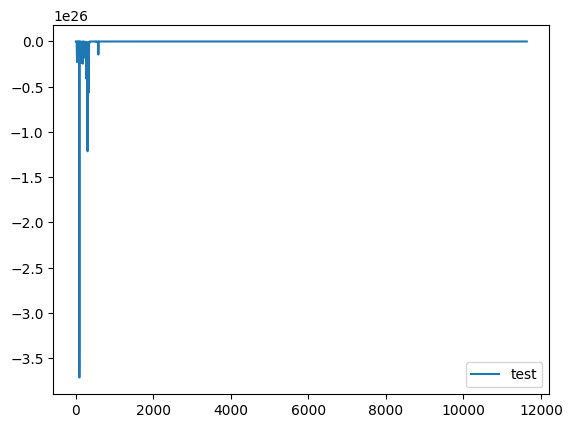

106
[-0.1498842535943281, -45.19830109857663, -97.59656394019467, -2.272368026141602e+25, -0.04310019674385335, -1.0207477086144965, -5.56123615051447e+23, -0.9993086078387483, -0.5116328470513465, -3.7144917311347955e+26, -6.072675432246627e+22, -4.0238703825215396e+21, -0.014932546549172976, -7.587815636043656e+24, -2.381152143004766e+25, -9.524245344068808e+23, -0.5178831010578551, -9.557649196936071e+24, -2.4541527505103572e+25, -1.8400598821037266e+23, -5.0092239100975324e+23, -1.1621654727003833e+23, -3.7092063637168594e+23, -7.312978217161672e+23, -1.8241803912252523e+25, -3.793328020731029e+23, -6.932957797764864e+23, -4.118739153494672e+25, -5.3775074923872386e+23, -1.7009794037938493e+25, -1.2133509338985638e+26, -2.7687069802540423e+24, -9.625630097009577e+23, -5.650406849817855e+25, -8.694793422417716e+23, -1.437908070066197e+24, -2.8849420748155125e+22, -1.024801521984076e+22, -1.1307037842566443e+22, -1.3350400284966965e+23, -1.35642520808331e+22, -3.043723120177811e+21, 

<Axes: ylabel='Frequency'>

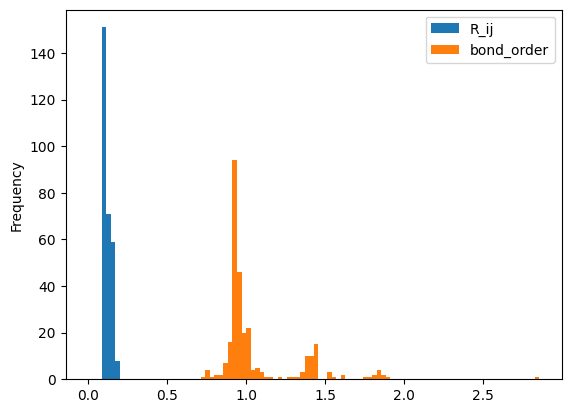

In [21]:
#plt.plot(train_size, train_scores, label="train")
plt.plot(train_size, test_scores, label="test")
plt.legend(loc='best')
plt.show()
print(len(oddities))

#print(oddities[103])
print(test_scores)
print(oddities_scores[103])
oddities[103].plot.hist(bins=100)


In [14]:
scores = cross_validate(XGBRegressor(), X_shuf, y_shuf, scoring='r2', cv=20, return_train_score=True)


In [25]:
print(scores["test_score"].mean())
print(scores["train_score"].mean())

0.7331227815336948
0.8021947143288758


In [33]:
train_size_abs, train_scores, test_scores = learning_curve(XGBRegressor(), X, y, shuffle = True, train_sizes=np.linspace(0.1, 1, 20), cv=20)

[0.93291986 0.90481151 0.8848977  0.86788541 0.85692137 0.84758657
 0.8405401  0.83279164 0.82524176 0.82284551 0.81837473 0.81779592
 0.8148724  0.81220496 0.81041638 0.80829022 0.80599874 0.80636997
 0.80549034 0.80387031]
[ 1106  1630  2153  2677  3201  3725  4249  4773  5297  5821  6345  6869
  7393  7917  8441  8965  9489 10013 10537 11061]


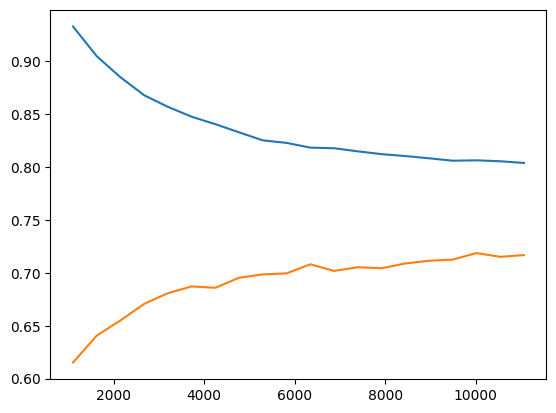

In [44]:
print(train_scores.mean(axis=1))
print(train_size_abs)
plt.plot(train_size_abs,train_scores.mean(axis=1))
plt.plot(train_size_abs, test_scores.mean(axis=1))


In [45]:
print(train_scores)

[[0.94010042 0.93675533 0.92720369 0.92504772 0.94959115 0.92673108
  0.92243346 0.9361213  0.93683341 0.94960365 0.94066918 0.93516148
  0.93163466 0.91443036 0.92472968 0.92618183 0.93136084 0.94331942
  0.92309369 0.93739476]
 [0.90314078 0.91987058 0.90557682 0.89666345 0.90723311 0.92569161
  0.89936828 0.90339192 0.89219881 0.91943863 0.90955688 0.9131603
  0.90222836 0.90002825 0.90062877 0.88558766 0.91529735 0.89407465
  0.8821491  0.92094487]
 [0.8816316  0.90493665 0.86805323 0.87889204 0.90621886 0.88862741
  0.89565921 0.89451323 0.86992274 0.89063475 0.87509216 0.88526835
  0.88326689 0.89638103 0.88203399 0.8782627  0.86860952 0.88825737
  0.86063654 0.90105575]
 [0.86506247 0.89083193 0.87376433 0.8560672  0.87550327 0.8704064
  0.86918621 0.87517057 0.84996509 0.87669626 0.86356901 0.86464583
  0.86826016 0.87029023 0.86451482 0.86102148 0.86450159 0.86085679
  0.84123555 0.89615909]
 [0.86671858 0.87014395 0.86643791 0.84277637 0.87673305 0.85244971
  0.86488804 0.861